# Donut 요소(Element) 파인튜닝 노트북 — 논문식 구조화 JSON · 고DPI(elements_hidpi) 버전

`donut_training_elements_paper.ipynb`(논문식 구조화 JSON)와 **동일한 파이프라인**이며, 학습 데이터만 **고DPI 재취득 크롭 `data/elements_hidpi`** 로 바꾼 버전입니다.

- **입력**: YOLO-OBB 가 검출·정렬(rectify)한 element 크롭 (치수 / 공차 / GD&T / 거칠기) — 고DPI 재취득본
- **정답(학습 타깃)**: 카테고리별 **구조화 JSON** 을 토큰화 (`<s_geometricCharacteristic>⊥</s_geometricCharacteristic><s_tolerance>Ø0.12(M)</s_tolerance>…`). 모델이 **필드 구조를 직접** 생성.
- **`parse_to_schema` 의 역할 이동**: flat 노트북에선 *모델 출력의 사후처리*였지만, 여기선 *학습 타깃(구조화 JSON)을 만드는 전처리*. 추론/평가에선 `token2json` 으로 모델이 낸 구조를 바로 복원(사후 정규식 불필요).
- 기호(Ø,⊥,±,°)는 **토크나이저에 실제 토큰으로 등록**(U+XXXX 폐기). 평가는 **field-level P/R/F1 + 글자유사도**. 타입은 YOLO 제공.
- **체크포인트**: 기존 paper 버전과 분리해 `checkpoints_elements_paper_hidpi/` 에 저장.

> **데이터 준비**: 고DPI 재취득 파이프라인으로 `data/elements_hidpi/{images,labels}` 생성 + 검증셋 목록 `val_ids.txt`. 아래 split 셀이 `val_ids.txt` 를 val 로 고정하고 나머지를 train 으로 분리해 `data/processed_elements_hidpi/{train,val}` 로 저장.
> **커널**: `donut_vml` (검출 YOLO + 인식 Donut 의존성이 모두 설치된 단일 커널 — 커널 전환 불필요).

### 📄 논문 기법 재현 — 카테고리별 구조화 JSON (Khan et al. 2025/2026)

이 노트북은 두 논문의 **Numerical VLM(=element 값 인식)** 방법 중 **카테고리별 구조화 JSON 직접 생성**을 재현한 버전입니다. (flat 변형판은 자매 노트북 `donut_training_elements_flat.ipynb`.)
> Khan et al., *"A Multi-Stage Hybrid Framework…"* (arXiv:2510.21862) · *"From Drawings to Decisions"* (RCIM 2026).
> element 값 인식 F1 — *From Drawings to Decisions* **0.935**(11,469 크롭) · *Multi-Stage Hybrid*(arXiv:2510.21862) **0.963**(~13,000 크롭, 1,406 도면).

**이 노트북(논문식) ↔ flat 노트북 차이**
1. **학습 타깃** — *논문식(여기)*: 카테고리별 구조화 JSON 을 모델이 **직접 생성**(`<s_geometricCharacteristic>…</s_tolerance>…`). *flat*: 통짜 값 한 개(`<s_value>…</s_value>`)만 생성하고 구조 분해는 사후 정규식.
2. **`parse_to_schema` 위치** — *논문식(여기)*: 학습 **타깃을 만드는 전처리**. *flat*: 모델 **출력의 사후처리**.
3. **추론** — *논문식(여기)*: `token2json` 으로 모델이 낸 구조를 바로 복원. *flat*: 통짜 값 → 정규식 구조화.
4. **공통** — 기호(Ø,⊥,±,°)는 토크나이저 실제 토큰 등록(U+XXXX 폐기), 숫자 0-9 등록, 평가는 field-level P/R/F1 + 글자유사도.

> 📌 **기호 인코딩만은 논문과 다름**: 논문은 `"U+2316"` 식 ASCII 코드포인트 문자열을 값에 넣지만, 이 노트북은 (구조화 방식은 논문대로 따르되) 기호를 토크나이저 실제 토큰으로 등록하는 개선을 유지합니다 — 8글자 코드를 외워 생성하는 부담 제거. **이제 `USE_UNICODE_SYMBOLS` 토글(헬퍼 셀)로 두 방식을 모두 지원하며, 이 hidpi 버전의 기본값은 토큰 등록 방식(`USE_UNICODE_SYMBOLS=False`)입니다** — 논문 완전 재현(U+XXXX 인코딩)으로 바꾸려면 `USE_UNICODE_SYMBOLS=True`.

**⚠️ 결정적 제약 = 데이터 양 + 품질 둘 다.** 논문 numeric VLM 은 **~11,000–13,000 크롭**으로 F1 0.93–0.96 달성(이 프로젝트 **1,975 = 약 1/7**, 블러·저해상). 단 소량·편중(GD&T 180·Hole 70)에선 중첩 태그 직접 생성이 불안정하니 **~1만+ 고품질 크롭 + 정교 스키마** 확충이 길. (재진단: `Element_Donut_성능미달_원인_및_해결방안.md`)

#### 🔣 기호 인코딩 방식 비교 — Unicode 코드포인트 vs 실제 토큰 등록

도면 기호(⊥·⊕·Ø·±·°…)는 BART 기본 vocab 에 단일 토큰으로 없어, 그냥 두면 UNK/바이트 조각으로 깨진다. 두 해법의 트레이드오프:

| | **A. Unicode 코드포인트 문자열** (논문) | **B. 실제 토큰 등록** (이 노트북) |
|:--|:--|:--|
| 라벨/생성 | `⊥` → 텍스트 `"U+27C2"` (ASCII 6자 생성) | `⊥` → 글리프 토큰 **1개** 생성 |
| 토크나이저 | **변경 없음** | `add_tokens` + `resize_token_embeddings` |
| **장점** | ① ASCII는 **사전학습 임베딩 재사용**(미학습 임베딩 0) → **저데이터에 강함**<br>② OOV/UNK 없음<br>③ `Ø`/`⌀`/`∅` 를 표준 코드로 **정규화**(인식 분산↓)<br>④ 순수 ASCII라 **이식성**(인코딩/폰트에 안 깨짐)<br>⑤ 토크나이저 미변경 → 체크포인트 동기화 이슈 없음 | ① **기호 1개=토큰 1개** → 짧은 시퀀스, 빠른 디코딩, max_length 여유<br>② "글리프 그림→글리프 토큰" **직관적·합성적** 매핑<br>③ GT·예측이 **사람이 읽는 실제 기호** → 역매핑 불필요<br>④ 8자 코드 암기 부담 제거 |
| **단점** | ① 기호 1개=~6토큰 → 시퀀스 길어짐, 틀릴 기회↑<br>② 글리프↔16진수 **임의 매핑 암기**(비직관)<br>③ hex 한 자리 오류=*다른 기호*/잘림 등 **조용한 오류**<br>④ 표시·사용 시 **역매핑 후처리 필수** | ① 새 토큰 임베딩 **랜덤 초기화 → 희소 기호는 미학습**(저데이터 결정적 약점) ⚠️<br>② 토크나이저↔모델 **동기화 부담**(체크포인트 저장 필수)<br>③ 미등록 기호 **OOV**(라벨 스캔 누락 주의)<br>④ NFKC 호환문자 등록 시 **평문 하이재킹**(예 Ⓜ→M) 위험 |
| **유리한 상황** | 데이터 적음 · 글리프 변형 표준화 필요 · 토크나이저 못 건드릴 때 | 기호별 예시 충분 · 짧은 시퀀스/읽기 쉬운 출력 우선 |

> **핵심 한 줄** — A: *학습된 토큰 재사용·표준화·견고* ↔ 긴 시퀀스·암기·후처리. / B: *짧고 직관·사람이 읽음* ↔ **희소 기호 임베딩 미학습**·토크나이저 관리.
>
> ⚠️ **이 프로젝트의 역설**: 노트북은 "암기 부담 제거"로 **B** 를 택했지만, 지배적 실패(°·⊥·∡ 누락·환각 — 분석 셀 #2·#3·#7)가 정확히 **B 의 약점(희소 기호 임베딩 미학습)**. → ① 희소 기호 **데이터 확충**으로 임베딩을 충분히 학습시키거나, ② 새 토큰 임베딩을 **랜덤 대신 의미있는 값으로 초기화**(예: 기호 설명 텍스트 평균 임베딩)하면 B 의 저데이터 약점이 완화된다. 완전한 논문 재현이 필요하면 `parse_to_schema` 출력 값에 U+XXXX 매핑을 적용해 **A** 로 전환.
>
> 🔧 **이 노트북 구현**: `USE_UNICODE_SYMBOLS` 토글로 A·B 모두 지원 — 이 hidpi 버전 기본값은 **B(글리프 토큰 등록 — U+XXXX 철자 깨짐 회피)**, A(논문 완전 재현)로 전환하려면 `USE_UNICODE_SYMBOLS=True`. `encode_symbols`/`decode_symbols`(헬퍼 셀)가 변환을 담당하고, 학습 타깃은 `encode_tree(parse_to_schema(...))`, 추론·평가는 `decode_tree`/`decode_symbols` 로 글리프 복원.

## 파인튜닝 핵심 개념 (요약)

### 전체 흐름

```
    [element 크롭]                    [정답 JSON]
           │                               │
           ▼                               ▼
  ┌─────────────────┐           ┌──────────────────┐
  │  DonutProcessor │           │   json2token()   │
  │  resize / norm  │           │   dict → token   │
  └────────┬────────┘           └────────┬─────────┘
           │ pixel_values                │ target_seq
           └──────────────┬──────────────┘
                          ▼
       ╔══════════════════════════════════════╗
       ║      VisionEncoderDecoderModel       ║
       ║   Swin-T (Encoder) → BART (Decoder)  ║
       ╚═════════════════╤════════════════════╝
                         ▼  logits
                  CrossEntropyLoss → 역전파
```

### 구성 요소 한 줄 정리

| 구성 | 역할 |
|:---|:---|
| **DonutProcessor** | 크롭 이미지 → 리사이즈(`384×384`)·정규화(`[-1,1]`) → `pixel_values` |
| **Swin-T** (encoder) | 이미지 → 시각 특징 |
| **BART** (decoder) | 시각 특징 + 이전 토큰 → 다음 토큰 |
| **json2token / token2json** | dict ↔ `<s_key>값</s_key>` 토큰 상호 변환 |

### 학습 방식 & loss (핵심만)

- **Teacher Forcing**: 학습 땐 이전 *정답* 토큰을 입력으로 줘 안정·빠르게 학습. (추론 땐 이전 *예측* 토큰을 사용)
- **Loss**: 정답 토큰을 맞히는 CrossEntropy. 라벨의 **패딩 위치는 `-100`** 으로 마스킹해 loss 에서 제외.
- **과적합 점검**: `train_loss`는 계속 ↘ 인데 `eval_loss`가 ↗ 로 돌아서면 과적합.
  → `EarlyStoppingCallback` 이 best 지점에서 학습 중단, `load_best_model_at_end` 가 best 가중치 복원.

> 🔹 **환경 점검** — tqdm 위젯 비활성화, PyTorch·Transformers 버전과 GPU(CUDA) 인식 여부 확인.

In [1]:
# ── widget 렌더러 오류 방지 (VS Code Jupyter) ─────────────────────
# tqdm.auto 및 HuggingFace 내부 progress bar가 ipywidget을
# 사용하지 않도록 강제합니다 — 텍스트 모드로 출력됩니다.
import os
os.environ['TQDM_NOTEBOOK'] = 'false'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'  # tokenizer 경고 억제

# ── Step 0: 환경 확인 ──────────────────────────────────────────────
# 학습에 필요한 라이브러리 버전과 GPU 상태를 먼저 점검합니다.
# CUDA가 False이면 GPU를 인식하지 못한 것 — 드라이버/환경을 확인하세요.
import torch
import transformers
import platform

print(f"Python     : {platform.python_version()}")
print(f"PyTorch    : {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"CUDA 사용   : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    print(f"VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


/home/jhkim/anaconda3/envs/donut_vml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python     : 3.10.20
PyTorch    : 2.11.0+cu128
Transformers: 5.12.1
CUDA 사용   : True
GPU        : NVIDIA GeForce RTX 5090
VRAM       : 33.7 GB


> 🔹 필수 패키지(datasets·sentencepiece) 설치 여부 확인 후 없으면 자동 설치.

In [2]:
# ── 필수 패키지 설치 확인 ─────────────────────────────────────────
# 이미 설치된 경우 무시됩니다 — 매번 실행해도 안전합니다.
# datasets  : HuggingFace 데이터셋 다운로드 라이브러리
# sentencepiece : Donut 토크나이저가 내부적으로 사용하는 형태소 분석기
import importlib, subprocess, sys

required = {"datasets": "datasets", "sentencepiece": "sentencepiece"}
missing  = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]

if missing:
    print(f"설치 중: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing, "-q"])
    print("설치 완료 — 커널을 재시작하지 않아도 됩니다.")
else:
    print("모든 패키지 설치 확인 ✓")


모든 패키지 설치 확인 ✓


> 🔹 학습 전반에 쓰는 공통 라이브러리(json·torch·PIL·Donut 클래스 등) import.

In [3]:
# ── 공통 Import ───────────────────────────────────────────────────
import json       # JSON 파일 읽기/쓰기
import os         # 파일 경로, 디렉터리 생성
import random     # 데이터셋 셔플 및 시드 고정
import re         # 정규표현식 (토큰 파싱에 사용)
import shutil
from pathlib import Path  # 운영체제 독립적인 파일 경로 처리

import numpy as np         # 수치 연산 및 시드 고정
from PIL import Image      # 이미지 파일 열기/변환
# tqdm.auto는 VS Code Jupyter에서 ipywidget 오류를 유발하므로 tqdm 직접 사용
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader  # 커스텀 데이터셋 클래스

from transformers import (
    DonutProcessor,              # 이미지 전처리 + 텍스트 토크나이저 통합 유틸리티
    VisionEncoderDecoderModel,   # 인코더(Swin-T) + 디코더(BART) 통합 모델
    Seq2SeqTrainer,              # Seq2Seq 학습 자동화 (forward/backward/저장)
    Seq2SeqTrainingArguments,    # 학습 하이퍼파라미터 설정
)

# ── matplotlib 전역 스타일 설정 ────────────────────────────────────
# 흰 배경에서도 텍스트/축/선이 선명하게 보이도록 전역 적용
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    "figure.facecolor": "white",   # 그림 배경 흰색
    "axes.facecolor":   "white",   # 축 영역 배경 흰색
    "savefig.facecolor":"white",   # 저장 시에도 흰 배경
    "text.color":       "black",   # 모든 텍스트 검정
    "axes.labelcolor":  "black",   # 축 레이블 검정
    "xtick.color":      "black",   # x축 눈금 검정
    "ytick.color":      "black",   # y축 눈금 검정
    "axes.edgecolor":   "black",   # 축 테두리 검정
})

# ── 한글 폰트 설정 (plot 한글 깨짐 / Glyph 경고 방지) ──────────────
# 시스템의 Noto Sans CJK(KR 포함)를 등록해 matplotlib 기본 폰트로 사용
from matplotlib import font_manager as _fm
_ko_font = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
try:
    _fm.fontManager.addfont(_ko_font)
    matplotlib.rcParams["font.family"] = _fm.FontProperties(fname=_ko_font).get_name()
except Exception as _e:
    print("한글 폰트 등록 실패(영문만 표시됨):", _e)
matplotlib.rcParams["axes.unicode_minus"] = False   # 마이너스 기호 깨짐 방지

print("Import 완료 ✓  (한글 폰트:", matplotlib.rcParams["font.family"], ")")


한글 폰트 등록 실패(영문만 표시됨): [Errno 2] No such file or directory: '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc'
Import 완료 ✓  (한글 폰트: ['sans-serif'] )


> 🔹 **공통 헬퍼 정의** — 토큰 변환(`json2token`/`token2json`, 리스트 `<sep/>` 복원 포함) · 카테고리별 구조화 파서(`parse_to_schema`, **학습 타깃 생성용**) · field-level F1·hallucination·값 글자유사도.

In [4]:
# ── 공통: 스키마·토큰·문자 헬퍼 (논문식 구조화 JSON 학습) ──
# [A] 기호 인코딩 모드(USE_UNICODE_SYMBOLS):
#   True  = 논문(Khan et al.) 완전 재현 — 비-ASCII 기호(Ø,⊥,±,° …)를 "U+XXXX" ASCII 코드포인트로 인코딩.
#           학습 타깃은 parse_to_schema 출력에 encode_tree 적용(Step 3a), 추론/평가는 decode_tree 로 글리프 복원.
#   False = 기호를 토크나이저 '실제 토큰'으로 등록(항등; Step 2 add_tokens).
USE_UNICODE_SYMBOLS = False  # ★ 논문 재현=True / 토큰등록 방식=False (hidpi: 글리프 토큰 등록 — U+XXXX 철자 깨짐 회피)
# [B] 학습 타깃 = 카테고리별 '구조화 JSON' 을 그대로 토큰화(json2token) → 모델이 중첩 태그를 '직접' 생성.
#     parse_to_schema 는 flat 노트북에선 '사후처리'였지만, 여기선 '학습 타깃을 만드는 전처리'로 쓰인다.
import re
from difflib import SequenceMatcher

def encode_symbols(s):            # 비-ASCII 글리프 → "U+XXXX"(논문식). 토큰등록 모드면 항등.
    s = str(s)
    if not USE_UNICODE_SYMBOLS: return s
    return "".join(c if ord(c) < 128 else f"U+{ord(c):04X}" for c in s)
def decode_symbols(s):            # "U+XXXX"(4자리 hex) → 글리프 역변환. 토큰등록 모드면 항등.
    s = str(s)
    if not USE_UNICODE_SYMBOLS: return s
    return re.sub(r"U\+([0-9A-Fa-f]{4})", lambda m: chr(int(m.group(1), 16)), s)
def _walk(o, fn):
    if isinstance(o, dict): return {k: _walk(v, fn) for k, v in o.items()}
    if isinstance(o, list): return [_walk(v, fn) for v in o]
    return fn(str(o))
def encode_tree(o): return _walk(o, encode_symbols)
def decode_tree(o): return _walk(o, decode_symbols)

def json2token(obj, sort_keys=True):
    """dict/list → Donut XML 토큰. {"a":"1"} → <s_a>1</s_a>; 리스트는 <sep/> 로 결합."""
    if isinstance(obj, dict):
        out = ""
        for k in (sorted(obj, reverse=True) if sort_keys else obj):
            out += f"<s_{k}>" + json2token(obj[k], sort_keys) + f"</s_{k}>"
        return out
    if isinstance(obj, list):
        return "<sep/>".join(json2token(v, sort_keys) for v in obj)
    return str(obj)

def token2json(tokens):
    """<s_k>v</s_k> → dict (json2token 역변환). 값에 <sep/> 있으면 리스트로 복원."""
    out = {}
    while tokens:
        st = re.search(r"<s_(.+?)>", tokens)
        if not st: break
        key = st.group(1); end = f"</s_{key}>"; ep = tokens.find(end, st.end())
        if ep == -1: break
        val = tokens[st.end():ep]
        if "<s_" in val:
            out[key] = token2json(val)
        elif "<sep/>" in val:
            out[key] = [p.strip() for p in val.split("<sep/>") if p.strip()]
        else:
            out[key] = val.strip()
        tokens = tokens[ep+len(end):]
    return out if out else tokens.strip()

# ── 카테고리별 스키마 파서: flat 값 → 구조화 dict ──
# 논문식 노트북에서는 '학습 타깃(구조화 JSON)을 만드는 전처리'로 사용:
# 라벨 {type:"통짜값"} → parse_to_schema(type, 값) → {quantity, nominalValue, …} → json2token → 디코더 타깃.
def _parse_measure(v):
    o = {}; s = v.strip()
    m = re.match(r"^\s*(\d+)\s*[xX×*]\s*(.+)$", s)            # 수량  N× / NX
    if m: o["quantity"] = m.group(1); s = m.group(2).strip()
    m = re.search(r"±\s*([0-9.,]+)", s)                       # 대칭 공차 ±t
    if m:
        o["upperLimit"] = "+" + m.group(1); o["lowerLimit"] = "-" + m.group(1)
        s = re.sub(r"\s+", " ", s[:m.start()] + s[m.end():]).strip()   # 접합부 이중 공백 정규화
    else:
        m = re.search(r"\+\s*([0-9.,]+)\s*(?:/\s*-|[-/])\s*([0-9.,]+)", s)   # 비대칭 +a/-b · +a -b · +a/b
        if m:
            o["upperLimit"] = "+" + m.group(1); o["lowerLimit"] = "-" + m.group(2)
            s = re.sub(r"\s+", " ", s[:m.start()] + s[m.end():]).strip()   # 매치 뒤 꼬리((M) 등)도 보존
    if s: o["nominalValue"] = s
    return o or {"nominalValue": v.strip()}

GDT_CHARACTERISTICS = "⊥∥∠⊕◎⌭⌒⌓⏥⏤⌯↗⌰⟂⌖○"   # 기하특성 글리프만 — Ø·⌀·± 는 공차 소속이라 포함 금지
def _parse_gdt(v):
    o = {}; s = v.strip()
    m = re.match(rf"^([{GDT_CHARACTERISTICS}]+)\s*(.*)$", s)  # 선두 기하특성 글리프 (Ø0.12… 의 Ø 오분류 방지)
    if m and m.group(1).strip():
        o["geometricCharacteristic"] = m.group(1).strip(); s = m.group(2).strip()
    m = re.search(r"(?:(?<=\s)|^)((?:[A-Z]{1,2}\s+)*[A-Z]{1,2})\s*$", s)  # 후미 데이텀(1~2글자, 공백 구분 — AA 지원)
    if m:
        dats = m.group(1).split()
        if dats: o["datumReference"] = dats; s = s[:m.start()].strip()
    if s: o["tolerance"] = s
    return o or {"tolerance": v.strip()}

def _norm_value(s):
    """디코드 아티팩트 공백 정리: 소수점·부호·기호 주변 공백 제거(데이텀 글자 사이 공백은 보존)."""
    s = re.sub(r"\s*\.\s*", ".", str(s))                 # "0 .1" → "0.1"
    s = re.sub(r"([+\-±°Ø∅⌀⊥∡∥])\s+", r"\1", s)         # 기호/부호 바로 뒤 공백 제거
    s = re.sub(r"\s+°", "°", s)                          # 도(°) 앞 공백
    return s.strip()

def parse_to_schema(cls, value):
    """{class: value} 의 value → 카테고리별 구조화 dict."""
    v = str(value)
    if cls in ("Dimension", "Measure", "Measures", "Radii", "Radius"): return _parse_measure(v)
    if cls in ("GD&T_FCF", "GD&T", "GDT"):                             return _parse_gdt(v)
    if cls == "Surface_Roughness":                                     return {"roughness": v.strip()}
    if cls == "Datum":                                                 return {"datum": v.strip()}
    return {"value": v.strip()}                                        # Hole_Callout 등

# ── 평가: field-level P/R/F1 + hallucination, + 값 글자유사도 ──
def _flatten(d, pre=""):
    it = {}
    if isinstance(d, dict):
        for k, v in d.items(): it.update(_flatten(v, f"{pre}/{k}"))
    elif isinstance(d, list):
        # 단일 원소 리스트는 스칼라와 동일 경로로 — json2token 이 sep 없이 직렬화해 token2json 이 str 로
        # 복원하므로, 리스트 GT(["A"]) vs str 예측("A")이 경로 불일치로 오답 처리되는 것을 방지.
        if len(d) == 1: it.update(_flatten(d[0], pre))
        else:
            for i, v in enumerate(d): it.update(_flatten(v, f"{pre}[{i}]"))
    else: it[pre] = re.sub(r"\s+", "", str(d))
    return it

def field_prf1(pred, gt):
    pf, gf = _flatten(pred), _flatten(gt)
    tp = sum(1 for k, v in gf.items() if pf.get(k) == v)
    P = tp / max(1, len(pf)); R = tp / max(1, len(gf)); F = 2*P*R / max(1e-9, P+R)
    return P, R, F, (1 - P)

def value_charsim(a, b):    # leaf 값 글자유사도(진전 가시화: exact 0 에 묻힌 부분정답)
    na = re.sub(r"\s+", "", str(a)); nb = re.sub(r"\s+", "", str(b))
    return SequenceMatcher(None, na, nb).ratio()

# ── 타입 조건부 디코딩: YOLO 타입의 스키마 필드 태그만 허용(다른 카테고리 태그는 suppress) ──
# 추론 시 타입은 YOLO 가 이미 안다 → 그 타입에 없는 필드 태그를 generate 단계에서 막아
# 교차-카테고리 구조 환각(예: Dimension 인데 <s_geometricCharacteristic> 생성)을 차단.
# ★ CATEGORY_FIELDS 분기는 parse_to_schema 와 '반드시' 일치시킬 것(한쪽만 바꾸면 어긋남).
CATEGORY_FIELDS = {
    "measure":   {"quantity", "nominalValue", "upperLimit", "lowerLimit"},
    "gdt":       {"geometricCharacteristic", "tolerance", "datumReference"},
    "roughness": {"roughness"},
    "datum":     {"datum"},
    "value":     {"value"},
}
ALL_FIELDS = set().union(*CATEGORY_FIELDS.values())

def type_fields(cls):
    """element 타입 → 허용 필드키 집합 (parse_to_schema 분기와 동일)."""
    if cls in ("Dimension", "Measure", "Measures", "Radii", "Radius"): return CATEGORY_FIELDS["measure"]
    if cls in ("GD&T_FCF", "GD&T", "GDT"):                             return CATEGORY_FIELDS["gdt"]
    if cls == "Surface_Roughness":                                     return CATEGORY_FIELDS["roughness"]
    if cls == "Datum":                                                 return CATEGORY_FIELDS["datum"]
    return CATEGORY_FIELDS["value"]

def forbidden_tag_ids(tokenizer, cls):
    """이 타입에서 '쓰면 안 되는' 다른 카테고리 필드 태그(<s_k>,</s_k>)의 토큰 id 목록.
    generate(suppress_tokens=...) 로 넘겨 교차-카테고리 구조 환각을 차단."""
    forbid = ALL_FIELDS - type_fields(cls); unk = tokenizer.unk_token_id; ids = []
    for k in forbid:
        for tag in (f"<s_{k}>", f"</s_{k}>"):
            tid = tokenizer.convert_tokens_to_ids(tag)
            if tid is not None and tid != unk: ids.append(tid)
    return ids

print("스키마/토큰/문자 헬퍼 정의 완료 ✓ (논문식 구조화 JSON 학습 + field-level 채점 + 타입 조건부 디코딩)")

스키마/토큰/문자 헬퍼 정의 완료 ✓ (논문식 구조화 JSON 학습 + field-level 채점 + 타입 조건부 디코딩)


## Step 1 – 설정 (Configuration)

모든 하이퍼파라미터를 딕셔너리로 관리합니다.  
`dataset_name`을 `None`으로 바꾸고 `local_train_dir` / `local_val_dir`을 지정하면 커스텀 데이터셋을 사용할 수 있습니다.

> 🔹 **전역 설정(CFG) 정의** — 모델·데이터·학습 하이퍼파라미터와 구조화 스키마 방식 명시.

In [5]:
# ── Step 1: 설정 (Element Donut 파인튜닝용 · 논문식 구조화 JSON 직접 생성) ───
# YOLO 가 검출·분류한 element 크롭을 입력으로, 카테고리별 '구조화 JSON' 을 직접 생성하도록 Donut 파인튜닝.
#
# 설계(논문식): 타입은 YOLO 가 제공 → Donut 은 그 타입의 '구조화 필드'를 직접 생성.
#   타깃 = task_prompt(<s_element>) + json2token(parse_to_schema(type, raw)) + eos
#     예) Dimension "8X Ø6.5±0.1" →
#         <s_quantity>8</s_quantity><s_nominalValue>Ø6.5</s_nominalValue><s_upperLimit>+0.1</s_upperLimit><s_lowerLimit>-0.1</s_lowerLimit>
#   기호는 토크나이저에 실제 토큰으로 등록(U+XXXX 없음). 필드 분해는 '학습 타깃 생성 단계'에서 parse_to_schema 로 수행하고,
#   추론·평가에선 token2json 으로 모델이 낸 구조를 바로 복원(사후 정규식 불필요).
CFG = {
    "model": {
        "pretrained_model_name": "naver-clova-ix/donut-base",
        "max_length": 128,        # 구조화 태그가 붙어 flat 보다 길지만 element 단위라 128 이면 충분
        "image_size": [448, 448], # 384→448: 작은 적층 공차/미세 기호(⊥,°,.000/.001) 인식 개선 (VRAM↑; baseline 비교 땐 384)
    },
    "data": {
        "dataset_name": None,                       # 로컬 모드
        "task_prompt": "<s_element>",
        "local_train_dir": "../data/processed_elements_hidpi/train",
        "local_val_dir":   "../data/processed_elements_hidpi/val",
        "augment":  True,    # (나) on-the-fly 증강 (개선 런 ON; baseline 비교 시 False)
        "synth_n":  2500,    # (가') 희소클래스 전용 소량 — 과다희석(82%) 방지
        "synth_dir": "../data/elements_synth",   # (가) 합성 출력/병합 경로
        "synth_weights": "Dimension=0.15,Surface_Roughness=0,Datum=0,Section=0,GD&T_FCF=0.55,Hole_Callout=0.30",  # (가') 희소클래스(GD&T·Hole)만 생성 — Dimension 등 실데이터 충분
    },
    "training": {
        "output_dir": "../checkpoints_elements_paper_hidpi",   # ★ flat 버전(../checkpoints_elements)과 분리
        "num_epochs": 60,        # 상한값 — early_stopping_patience 로 더 일찍 종료됨
        "batch_size": 8,          # 작은 이미지 → 배치 확대 가능 (VRAM 부족 시 낮추기)
        "gradient_accumulation_steps": 2,
        "learning_rate": 3e-5,
        "warmup_steps": 50,
        "weight_decay": 0.01,
        "bf16": True,             # ★ fp16 은 Donut 에서 불안정 → bf16 고정
        "fp16": False,
        "save_steps": 50,
        "eval_steps": 50,
        "early_stopping_patience": 5,  # eval_loss 5회 연속 개선 없으면 조기 종료
        "logging_steps": 10,
        "dataloader_num_workers": 4,
        "seed": 42,
    },
    "wandb": {"enabled": False, "project": "donut-elements-paper", "run_name": None},
}
print("Config (element · 논문식 구조화 JSON) loaded ✓")
print(f"  태스크   : {CFG['data']['task_prompt']}")
print(f"  학습 출력: {CFG['training']['output_dir']}")

Config (element · 논문식 구조화 JSON) loaded ✓
  태스크   : <s_element>
  학습 출력: ../checkpoints_elements_paper_hidpi


> 🔹 재현성을 위한 난수 시드 고정(Python·NumPy·PyTorch·CUDA).

In [6]:
# ── 재현성을 위한 시드 고정 ────────────────────────────────────────
# 동일한 시드를 설정하면 같은 코드를 다시 실행해도 동일한 결과가 나옵니다.
# Python / NumPy / PyTorch / CUDA 각각의 난수 생성기를 모두 고정해야 합니다.
def set_seed(seed: int):
    random.seed(seed)        # Python 기본 random 모듈
    np.random.seed(seed)     # NumPy 난수
    torch.manual_seed(seed)  # CPU 연산 난수
    torch.cuda.manual_seed_all(seed)  # GPU 연산 난수 (멀티GPU 포함)

set_seed(CFG["training"]["seed"])
print(f"Seed = {CFG['training']['seed']} 고정 완료")


Seed = 42 고정 완료


## Element 데이터셋 준비 (train/val 분리)

`data/elements_hidpi/{images,labels}` (crop PNG + `{"<type>":"<value>"}` JSON) 을
`data/processed_elements_hidpi/{train,val}` 로 분리합니다. 라벨은 `detection/cvat_to_donut.py` 로 CVAT export 에서 생성.

> 🔹 element 크롭+라벨 쌍을 train/val 로 분리해 processed_elements_hidpi 디렉터리에 저장.

In [7]:
# ── element(고DPI) 데이터 train/val 분리 — val_ids.txt 고정 분리 ─────────────────
# elements_hidpi 는 고DPI 재취득 크롭. 검증셋이 val_ids.txt 로 미리 정해져 있어
# 랜덤 분리 대신 이 목록을 val 로 고정하고 나머지를 train 으로 둔다(분리 재현성·일관성 유지).
import shutil
from pathlib import Path

SRC = Path("../data/elements_hidpi")
OUT = Path("../data/processed_elements_hidpi")
VAL_IDS = SRC / "val_ids.txt"

img_dir, lbl_dir = SRC / "images", SRC / "labels"
pairs = {p.stem for p in img_dir.glob("*.png")
         if (lbl_dir / (p.stem + ".json")).exists()}
assert pairs, f"{SRC} 에 crop+label 쌍이 없습니다"

# val_ids.txt(파일명) → stem. 실제 존재하는 쌍만 val 로 채택(목록에 있으나 없는 이미지는 건너뜀).
val_listed = {Path(l.strip()).stem for l in VAL_IDS.read_text().splitlines() if l.strip()}
val_stems   = sorted(pairs & val_listed)
train_stems = sorted(pairs - set(val_stems))
missing     = sorted(val_listed - pairs)
splits = {"val": val_stems, "train": train_stems}

# 기존 분리 산출물 제거 후 재생성(과거 랜덤 분리 잔재 방지)
if OUT.exists():
    shutil.rmtree(OUT)
for split, names in splits.items():
    for sub in ("images", "labels"):
        (OUT / split / sub).mkdir(parents=True, exist_ok=True)
    for st in names:
        shutil.copy(img_dir / f"{st}.png",  OUT / split / "images" / f"{st}.png")
        shutil.copy(lbl_dir / f"{st}.json", OUT / split / "labels" / f"{st}.json")
print({k: len(v) for k, v in splits.items()})
if missing:
    print(f"⚠️ val_ids.txt 에 있으나 이미지가 없어 건너뜀: {len(missing)}개 → {missing}")

{'val': 98, 'train': 551}
⚠️ val_ids.txt 에 있으나 이미지가 없어 건너뜀: 2개 → ['A1394920840_p1_v1_e7_Dimension', 'BP003329600_p1_v1_e7_Dimension']


### (라) 라벨 노이즈 점검·정제  *(기본 report-only)*
`�`(U+FFFD)·제어문자·variation-selector 등 **깨진 라벨**을 스캔합니다. 실제 수정은 `APPLY=True` 로.

In [8]:
# (라) 라벨 노이즈 스캔/정제 — processed_elements_hidpi/{train,val}/labels
import os, json, glob, unicodedata, re
APPLY = True    # 개선 런: 노이즈(�·제어문자) 정제 적용 (되돌리려면 split 셀 재실행)
def _bad(ch):
    if ch in "�️": return True      # 깨짐(�)·variation selector
    if ch.isspace(): return False             # 줄바꿈/공백은 노이즈 아님 → 삭제 말고 공백 정규화
    return unicodedata.category(ch) in ("Cc", "Cf", "Co", "Cn")
tot = hit = 0; samples = []
for d in ("train", "val"):
    for f in glob.glob(f"../data/processed_elements_hidpi/{d}/labels/*.json"):
        g = json.load(open(f, encoding="utf-8")); k = next(iter(g)); v = str(g[k]); tot += 1
        bad = [c for c in v if _bad(c)]
        if bad:
            hit += 1
            if len(samples) < 12: samples.append((k, v))
            if APPLY:
                cleaned = re.sub(r"\s+", " ", "".join(c for c in v if not _bad(c))).strip()
                json.dump({k: cleaned}, open(f, "w", encoding="utf-8"), ensure_ascii=False)
print(f"노이즈 라벨: {hit}/{tot}" + ("  (정제 적용됨)" if APPLY else "  (report-only; APPLY=True 로 정제)"))
for k, v in samples: print(f"  [{k}] {v!r}")

# ── (라+) 구조적 라벨 의심 스캔 (report-only · 손수정 권장) ──────────────────
# 자동 수정 금지: 진짜 값은 이미지를 봐야 알 수 있음(소수점 위치 등). 의심 목록만 출력.
GDT_SYMS = set("⊥∥∠⊕◎⌭⌒⌓⏥⏤⌯↗⌰⟂⌖○")           # GD&T 기하특성 기호
def _suspect(cls, v):
    flags = []
    # ① 소수점 누락 의심: 부호+0 뒤로 점 없이 숫자 (예: +000, -001 → +0.00/-0.01 추정)
    if re.search(r"[+\-]0\d+", v) and "." not in v:
        flags.append("소수점누락?")
    # ② 오라벨 의심: Datum 라벨인데 GD&T 기호 포함 (예: Datum '⊥ A' → Datum 은 글자만이어야)
    #    ※ Surface_Roughness 의 ⊥ 는 lay(줄무늬 방향) 기호로 '정상' → 검사 대상에서 제외(Datum 한정).
    if cls == "Datum" and any(ch in GDT_SYMS for ch in v):
        flags.append("GD&T기호혼입?")
    # ③ 앞 군더더기 '-' : 숫자가 아닌 기호/문자 앞에 붙은 선두 마이너스 (예: -Ø.750)
    if re.match(r"^\s*-[^\d\s+]", v):
        flags.append("선두마이너스?")
    return flags

suspects = []
for d in ("train", "val"):
    for f in glob.glob(f"../data/processed_elements_hidpi/{d}/labels/*.json"):
        g = json.load(open(f, encoding="utf-8")); k = next(iter(g)); v = str(g[k])
        fl = _suspect(k, v)
        if fl: suspects.append((os.path.basename(f), k, v, fl))
print(f"\n구조적 의심 라벨: {len(suspects)} 건 (report-only — 이미지 대조 후 손수정)")
for fn, k, v, fl in suspects[:30]:
    print(f"  [{','.join(fl):<28}] {k:<16} {v!r:<24} ({fn})")
if len(suspects) > 30: print(f"  … 외 {len(suspects)-30} 건")

노이즈 라벨: 0/649  (정제 적용됨)

구조적 의심 라벨: 2 건 (report-only — 이미지 대조 후 손수정)
  [GD&T기호혼입?                   ] Datum            '⊥'                      (A1370954730_p1_v2_e3_Datum.json)
  [GD&T기호혼입?                   ] Datum            '⊥'                      (A1370954730_p1_v2_e4_Datum.json)


### (가) 합성 데이터 생성  *(기본 OFF)*
`CFG.data.synth_n>0` + `synth_dir` 설정 시 `detection/synth_elements.py` 로 공짜 라벨 크롭을 생성합니다.
생성 후 아래 `build_datasets` 가 **train 에만** 자동 병합(val 은 실데이터 유지).

In [9]:
# (가) 합성 데이터 생성 — CFG.data.synth_n > 0 일 때만
import subprocess, sys
_sn = CFG["data"].get("synth_n", 0); _sd = CFG["data"].get("synth_dir")
if _sn and _sd:
    _cmd = [sys.executable, "detection/synth_elements.py",
            "--n", str(_sn), "--out", _sd, "--seed", str(CFG["training"]["seed"])]
    _sw = CFG["data"].get("synth_weights")
    if _sw: _cmd += ["--weights", _sw]
    print(f"합성 {_sn}장 생성 → {_sd}" + (f"  (weights: {_sw})" if _sw else ""))
    subprocess.run(_cmd, check=True)
    print("합성 생성 완료 — build_datasets 가 train 에 병합합니다.")
else:
    print("합성 생성 건너뜀 (CFG.data.synth_n=0). 켜려면 CFG 에서 synth_n>0 + synth_dir 설정 후 재실행.")


합성 2500장 생성 → ../data/elements_synth  (weights: Dimension=0.15,Surface_Roughness=0,Datum=0,Section=0,GD&T_FCF=0.55,Hole_Callout=0.30)


생성 완료: 2500장 → ../data/elements_synth
  Dimension               391  (15.6%)
  GD&T_FCF               1374  (55.0%)
  Datum                     0  ( 0.0%)
  Surface_Roughness         0  ( 0.0%)
  Section                   0  ( 0.0%)
  Hole_Callout            735  (29.4%)

다음 단계: 이 합성셋을 실데이터(data/elements)와 **섞어** split → 재학습.
          성능 측정은 반드시 실검증셋(data/processed_elements/val)으로만.
합성 생성 완료 — build_datasets 가 train 에 병합합니다.


## Step 2 – 모델 & 프로세서 로드

- **DonutProcessor**: 이미지 전처리(resize/normalize) + 토크나이저
- **VisionEncoderDecoderModel**: 인코더(Swin-T) + 디코더(BART)

task token `<s_element>` 와 **라벨의 모든 타입 토큰**(`<s_dimension>` 등)을 토크나이저에 추가하고 임베딩을 확장합니다.
타입 토큰은 **train+val 라벨에서 모아 등록** — 희소 타입(예: roughness)이 한쪽 split 에만 있어도 누락되지 않습니다.

> 🔹 **Donut 모델·프로세서 빌드 함수 정의** — 이미지 크기·토큰·디코더 설정.

In [10]:
# ── Step 2: 모델 & 프로세서 빌드 (논문식 구조화 스키마 + 기호 토큰 등록) ──
def build_model_and_processor(cfg):
    model_cfg  = cfg["model"]; name = model_cfg["pretrained_model_name"]
    image_size = model_cfg["image_size"]; max_length = model_cfg["max_length"]
    processor = DonutProcessor.from_pretrained(name, backend="pil")
    model     = VisionEncoderDecoderModel.from_pretrained(name)
    processor.image_processor.size = {"height": image_size[0], "width": image_size[1]}
    processor.image_processor.do_align_long_axis = False  # 회전 안 함(가로 크롭 유지)
    processor.image_processor.do_thumbnail = True         # 종횡비 보존(비율 유지 축소)
    processor.image_processor.do_pad = True               # 남는 영역 패딩(찌부러뜨리지 않음)
    model.config.encoder.image_size = image_size
    model.config.decoder.max_length = max_length

    task_prompt = cfg["data"]["task_prompt"]
    # [B] 논문식 구조화 스키마: 모델이 카테고리별 중첩 JSON 토큰을 '직접' 생성.
    #   special 토큰 = task_prompt + <sep/> + (실제 라벨을 parse_to_schema 로 구조화했을 때 나오는 모든 필드키의 <s_k>/</s_k>).
    #   ★ 템플릿이 아니라 '실제 라벨'에서 키를 읽어야 디코더가 그 필드를 낼 수 있음(CLAUDE.md 주의사항).
    # ★ 합성 데이터(synth_dir)는 build_datasets 가 train 에 병합하므로 필드키·기호·OOV 스캔에도 포함.
    #   누락 시: 합성 전용 필드 태그(<s_geometricCharacteristic> 등)가 서브워드로 쪼개져 학습되고
    #   suppress_tokens 도 무력화되며, 합성 전용 기호(∥·⌖·⏥ 등)는 <unk> 로 들어가 타깃이 깨진다.
    scan_dirs = [cfg["data"]["local_train_dir"], cfg["data"]["local_val_dir"]]
    _syn = cfg["data"].get("synth_dir")
    if cfg["data"].get("synth_n", 0) and _syn and (Path(_syn) / "labels").exists():
        scan_dirs.append(_syn)
    field_keys = set()
    for _sd in scan_dirs:
        for _f in (Path(_sd) / "labels").glob("*.json"):
            _g = json.load(open(_f, encoding="utf-8")); _c = next(iter(_g)); _v = str(_g[_c])
            field_keys.update(parse_to_schema(_c, _v).keys())
    special = [task_prompt, "<sep/>"]
    for _k in sorted(field_keys):
        special += [f"<s_{_k}>", f"</s_{_k}>"]
    num_added = processor.tokenizer.add_special_tokens({"additional_special_tokens": special})
    print(f"구조 필드키({len(field_keys)}): {sorted(field_keys)}")

    # [A] 토큰등록 모드: 기호를 일반 토큰으로 등록. U+XXXX 모드: syms=[] (위). 숫자 0-9 는 항상 등록(미드-스트링 OOV 방지).
    import unicodedata
    val_chars = set()
    for _sd in scan_dirs:
        for _f in (Path(_sd) / "labels").glob("*.json"):
            for _v in json.load(open(_f, encoding="utf-8")).values():
                val_chars.update(str(_v))
    # 비-ASCII 중 NFKC 안정(자기자신=정규화결과)인 글자만 — 평문 하이재킹(Ⓜ→M 등) 방지
    # 논문 재현(U+XXXX)에선 기호가 ASCII 로 인코딩되므로 글리프 토큰 등록 불필요.
    syms = [] if USE_UNICODE_SYMBOLS else sorted(c for c in val_chars if ord(c) > 127 and unicodedata.normalize("NFKC", c) == c)
    n_sym   = processor.tokenizer.add_tokens(syms)
    n_digit = processor.tokenizer.add_tokens(list("0123456789"))

    if num_added or n_sym or n_digit:
        model.decoder.resize_token_embeddings(len(processor.tokenizer), mean_resizing=False)
    _enc = "U+XXXX(논문재현)" if USE_UNICODE_SYMBOLS else "글리프토큰"
    print(f"기호 인코딩: {_enc} | 토큰 추가: 구조 {num_added} + 기호 {n_sym}[{''.join(syms)}] + 숫자 {n_digit}")

    # OOV 진단: 라벨 값의 <unk> 포함 비율 (0% 에 수렴해야 함)
    unk = processor.tokenizer.unk_token_id; tot = bad = 0
    for _sd in scan_dirs:
        for _f in (Path(_sd) / "labels").glob("*.json"):
            for _v in json.load(open(_f, encoding="utf-8")).values():
                tot += 1
                _t = encode_symbols(str(_v)) if USE_UNICODE_SYMBOLS else str(_v)   # 실제 타깃 표현으로 검사
                if unk in processor.tokenizer(_t, add_special_tokens=False).input_ids: bad += 1
    print(f"값 <unk> 포함: {bad}/{tot} ({bad/max(1,tot)*100:.2f}%)")

    model.config.pad_token_id           = processor.tokenizer.pad_token_id
    model.config.decoder_start_token_id = processor.tokenizer.convert_tokens_to_ids(task_prompt)
    return model, processor


model, processor = build_model_and_processor(CFG)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)
enc_p = sum(p.numel() for p in model.encoder.parameters()) / 1e6
dec_p = sum(p.numel() for p in model.decoder.parameters()) / 1e6
print(f"디바이스 {device} | 인코더 {enc_p:.1f}M (Swin) / 디코더 {dec_p:.1f}M (BART)")
print(f"Decoder start token: {processor.tokenizer.convert_ids_to_tokens([model.config.decoder_start_token_id])}")

Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 484/484 [00:00<00:00, 74906.58it/s]

구조 필드키(10): ['datum', 'datumReference', 'geometricCharacteristic', 'lowerLimit', 'nominalValue', 'quantity', 'roughness', 'tolerance', 'upperLimit', 'value']


기호 인코딩: 글리프토큰 | 토큰 추가: 구조 22 + 기호 14[°±×Ø↗∠∡∥⊥⌀⌖⏥○◎] + 숫자 10
값 <unk> 포함: 0/3149 (0.00%)


디바이스 cuda | 인코더 74.2M (Swin) / 디코더 127.7M (BART)
Decoder start token: ['<s_element>']


## Step 3 – 데이터셋 구성 & 시각화

### DonutDataset 동작 원리

| 입력 | 처리 | 출력 |
|------|------|------|
| PIL Image | DonutProcessor → pixel_values | `(C, H, W)` Tensor |
| JSON ground truth | Tokenizer → teacher-forcing label | `(max_length,)` Token IDs |

**패딩 토큰 → -100**: CrossEntropyLoss는 `-100`으로 표시된 위치를 자동으로 무시합니다 (패딩 위치에서 loss 계산 안 함).

### 이 노트북의 데이터셋

로컬 element 크롭만 사용합니다 (`CFG.data.dataset_name = None`):

- `local_train_dir` / `local_val_dir` = `data/processed_elements_hidpi/{train,val}`
- 라벨 = element 1개당 `{"<type>": "<value>"}` (예: `{"dimension": "Ø65"}`) — **학습 타깃은 `parse_to_schema` 로 구조화한 카테고리별 JSON 을 `json2token` 으로 토큰화한 중첩 태그** — 모델이 필드 구조를 직접 생성(논문식). 통짜 값 타깃(flat)은 자매 노트북 `donut_training_elements_flat.ipynb`.

> `dataset_name` 에 HuggingFace ID(예: `naver-clova-ix/cord-v2`)와 그에 맞는 `task_prompt` 를 넣으면
> 공개 데이터셋으로도 학습할 수 있지만, 이 노트북의 목적은 **도면 element 인식**입니다.

> 🔹 **DonutDataset 클래스 정의** — 라벨을 `parse_to_schema` 로 구조화 후 `json2token` 으로 중첩 태그 타깃 생성(논문식).

In [11]:
# ── Step 3a: DonutDataset 정의 (논문식 구조화 JSON 타깃) ──────────────
# [B] 타깃 = task_prompt + json2token(parse_to_schema(type, raw)) + eos.
#   라벨 {type:"통짜값"} 을 카테고리별 구조화 dict 로 만든 뒤 토큰화 → 모델이 중첩 필드 태그를 '직접' 생성.
#   기호 표현은 USE_UNICODE_SYMBOLS 토글에 따름 — False(기본): 글리프 실제 토큰 / True: encode_tree 가 U+XXXX 인코딩.
class DonutDataset(Dataset):
    def __init__(self, dataset_or_root, processor, max_length: int, task_prompt: str, augment: bool = False):
        self.processor = processor; self.max_length = max_length; self.task_prompt = task_prompt
        self.augment = augment
        self.samples = self._load_local(Path(dataset_or_root))

    def _load_local(self, root: Path):
        exts = {".png", ".jpg", ".jpeg", ".tiff", ".bmp"}; out = []
        for ip in sorted((root / "images").glob("*")):
            if ip.suffix.lower() in exts:
                lp = root / "labels" / (ip.stem + ".json")
                if lp.exists(): out.append((ip, lp))
        return out

    def __len__(self): return len(self.samples)

    def _aug(self, img):   # (나) 약한 증강 — 작은 데이터 과적합 완화
        import random
        from PIL import ImageEnhance
        if random.random() < 0.5: img = ImageEnhance.Brightness(img).enhance(random.uniform(0.8, 1.2))
        if random.random() < 0.5: img = ImageEnhance.Contrast(img).enhance(random.uniform(0.8, 1.2))
        if random.random() < 0.3: img = img.rotate(random.uniform(-3, 3), expand=False, fillcolor=(255, 255, 255))
        return img

    def __getitem__(self, idx):
        ip, lp = self.samples[idx]
        image = Image.open(ip).convert("RGB")
        if self.augment: image = self._aug(image)
        gt  = json.load(open(lp, encoding="utf-8"))
        cls = next(iter(gt)); raw = str(gt[cls])               # {type: "통짜값"}
        struct = parse_to_schema(cls, raw)                     # → 카테고리별 구조화 dict
        target_seq = (self.task_prompt
                      + json2token(encode_tree(struct))        # 중첩 태그 (encode_tree 는 U+XXXX 모드만 변환, 글리프 모드는 항등)
                      + self.processor.tokenizer.eos_token)
        pixel_values = self.processor(image, return_tensors="pt").pixel_values.squeeze(0)
        labels = self.processor.tokenizer(target_seq, add_special_tokens=False,
            max_length=self.max_length, padding="max_length", truncation=True,
            return_tensors="pt").input_ids.squeeze(0)
        labels[labels == self.processor.tokenizer.pad_token_id] = -100
        return {"pixel_values": pixel_values, "labels": labels, "target_sequence": target_seq}

print("DonutDataset(논문식 구조화 JSON 타깃) 정의 완료 ✓")

DonutDataset(논문식 구조화 JSON 타깃) 정의 완료 ✓


> 🔹 설정에 따라 로컬/HuggingFace 데이터셋을 로드해 train·val Dataset 생성.

In [12]:
# ── Step 3b: 데이터셋 로드 ────────────────────────────────────────
# CFG 설정에 따라 HuggingFace 또는 로컬 디렉터리에서 데이터를 로드합니다.
# dataset_name이 지정되면 인터넷에서 자동 다운로드하고,
# None이면 local_train_dir / local_val_dir 경로를 사용합니다.
def build_datasets(cfg, processor):
    data_cfg   = cfg["data"]
    max_length = cfg["model"]["max_length"]
    prompt     = data_cfg["task_prompt"]

    if data_cfg.get("dataset_name"):          # HuggingFace 데이터셋
        from datasets import load_dataset
        # load_dataset은 처음 실행 시 다운로드 후 로컬에 캐시합니다
        raw      = load_dataset(data_cfg["dataset_name"])
        train_ds = DonutDataset(raw[data_cfg["train_split"]], processor, max_length, prompt)
        val_ds   = DonutDataset(raw[data_cfg["val_split"]],   processor, max_length, prompt)
    else:                                      # 로컬 디렉터리
        train_ds = DonutDataset(data_cfg["local_train_dir"], processor, max_length, prompt,
                                augment=data_cfg.get("augment", False))
        val_ds   = DonutDataset(data_cfg["local_val_dir"],   processor, max_length, prompt)

    # (가) 합성 데이터가 있으면 TRAIN 에만 병합 (val 은 실데이터 유지)
    # 폴더 존재만으로 병합하면 이전 런의 산출물이 남았을 때 synth_n=0(끔) 이어도 섞임 → synth_n 으로 게이트
    sdir = data_cfg.get("synth_dir")
    if not data_cfg.get("synth_n", 0):
        if sdir and (Path(sdir) / "images").exists():
            print("  (synth_dir 존재하지만 CFG.data.synth_n=0 → 병합 건너뜀)")
    elif sdir and (Path(sdir) / "images").exists():
        from torch.utils.data import ConcatDataset
        synth_ds = DonutDataset(sdir, processor, max_length, prompt, augment=data_cfg.get("augment", False))
        if len(synth_ds):
            train_ds = ConcatDataset([train_ds, synth_ds])
            print(f"  + 합성 {len(synth_ds):,} 장 병합 → train {len(train_ds):,}")

    return train_ds, val_ds


train_ds, val_ds = build_datasets(CFG, processor)
print(f"Train 샘플 수: {len(train_ds):,}")
print(f"Val   샘플 수: {len(val_ds):,}")


  + 합성 2,500 장 병합 → train 3,051
Train 샘플 수: 3,051
Val   샘플 수: 98


> 🔹 학습 샘플 3개를 이미지+정답 라벨과 함께 시각화해 데이터 로드 검증.

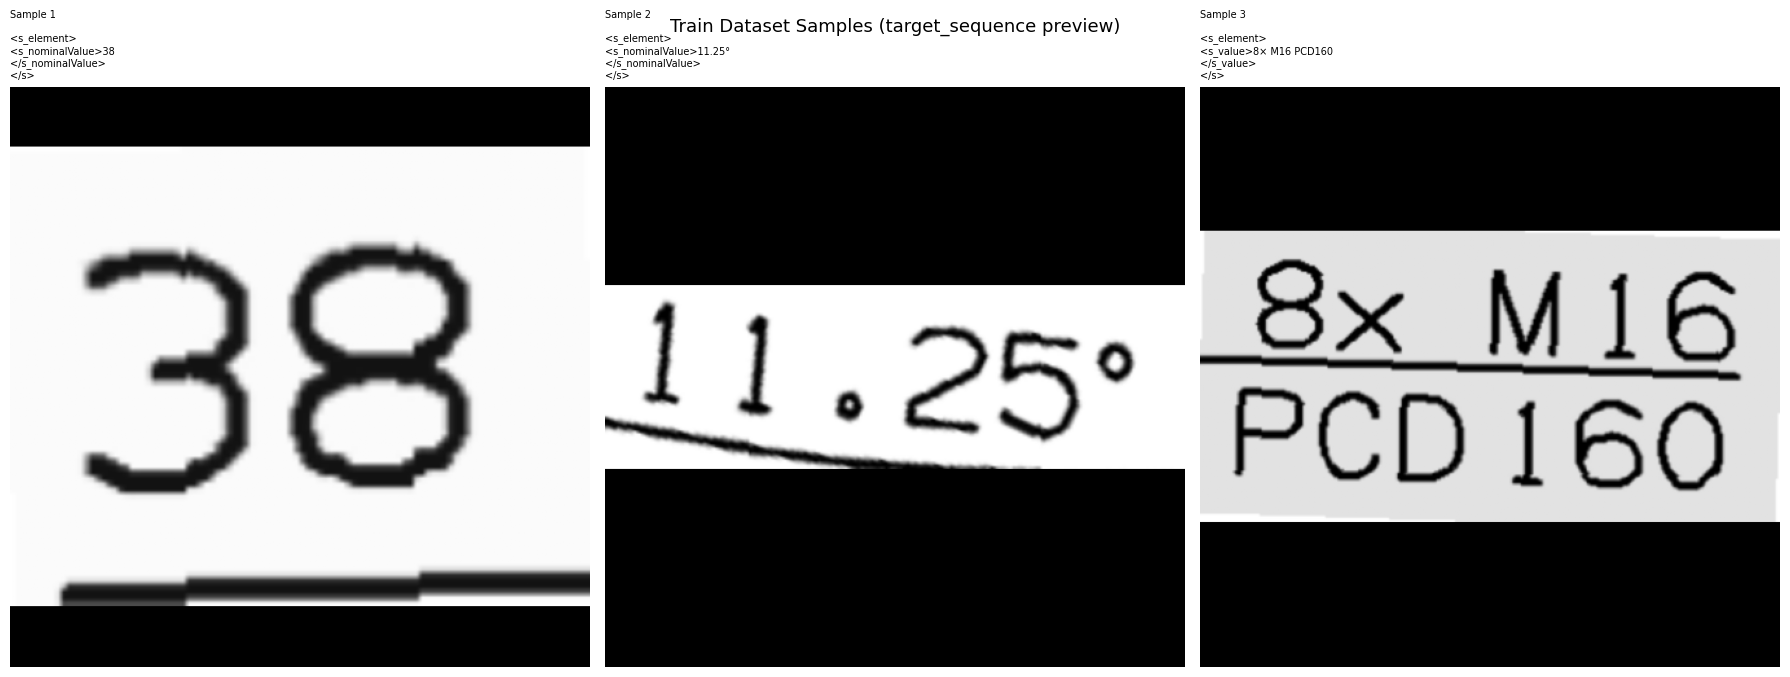


샘플 1 — 유효 토큰 수: 6 / 128
  (나머지 122개는 패딩 — loss 계산 제외)


In [13]:
# ── Step 3c: 샘플 시각화 ──────────────────────────────────────────
# 학습 데이터가 올바르게 로드됐는지 눈으로 확인합니다.
# 논문식 구조화 스키마라 타깃은 <s_element><s_필드>값</s_필드>…</s> 형태.
# 합성 병합 시 train_ds 가 ConcatDataset 이 될 수 있어, 파일 직접접근(.samples) 대신
# sample["target_sequence"] 로 미리보기합니다(두 타입 모두 동작).
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
PREVIEW_CHARS = 220   # 표시할 토큰 문자 수

for idx, ax in enumerate(axes):
    i = idx + 1  # 1,2,3번째 샘플
    sample = train_ds[i]

    # pixel_values는 [-1,1] 정규화 → [0,1] 로 되돌려 표시
    img_np = (sample["pixel_values"].permute(1, 2, 0).numpy() + 1) / 2
    ax.imshow(img_np.clip(0, 1)); ax.axis("off")

    gt_short = sample["target_sequence"][:PREVIEW_CHARS].replace("<", "\n<")
    ax.set_title(f"Sample {i}\n{gt_short}", fontsize=7, loc="left")

plt.suptitle("Train Dataset Samples (target_sequence preview)", fontsize=13)
plt.tight_layout(); plt.show()

# 유효 토큰 수: -100 아닌 위치 = 실제 정답 토큰 수
valid_tokens = (train_ds[1]["labels"] != -100).sum().item()
print(f"\n샘플 1 — 유효 토큰 수: {valid_tokens} / {CFG['model']['max_length']}")
print(f"  (나머지 {CFG['model']['max_length'] - valid_tokens}개는 패딩 — loss 계산 제외)")


## Step 4 – 학습 (Training)

`Seq2SeqTrainer` 로 학습합니다. 핵심 설정:

| 옵션 | 설명 |
|:---|:---|
| `bf16=True` | Donut 권장 혼합정밀도 (fp16 은 수치 불안정) |
| `gradient_accumulation_steps` | 실효 배치를 키우면서 VRAM 절감 |
| `predict_with_generate=False` | 평가는 `eval_loss` 만 측정(생성 생략 → 빠름). Leaf-Match 점수는 **Step 5b**에서 별도 계산 |
| `load_best_model_at_end=True` | 종료 후 `eval_loss` 최저 체크포인트 자동 복원 |
| `EarlyStoppingCallback(patience=5)` | `eval_loss` 가 5회 평가 연속 개선 없으면 조기 종료 (과적합 방지) |

> 🔹 Seq2SeqTrainer 로 Donut 파인튜닝 실행(학습·검증·체크포인트 저장·조기 종료).

In [14]:
# ── Step 4: 학습 실행 (클래스 균형 WeightedRandomSampler) ──────────────────
# Seq2SeqTrainer가 다음을 자동으로 처리합니다:
#   - 매 스텝: forward → loss 계산 → backward → 가중치 업데이트
#   - 매 eval_steps: 검증셋으로 eval_loss 측정 / 매 save_steps: 체크포인트 저장
#   - 학습 완료 후: eval_loss 최소 체크포인트 자동 복원
# ★ 데이터가 심하게 편중(Dimension≫GD&T·Hole) → 클래스 빈도 역수로 가중 샘플링해
#   희소 클래스(GD&T·Hole·기호)가 배치에 자주 등장하도록 함. (USE_BALANCED_SAMPLER 로 on/off)
USE_BALANCED_SAMPLER = True

if CFG["wandb"]["enabled"]:
    import wandb
    wandb.init(project=CFG["wandb"]["project"], name=CFG["wandb"]["run_name"], config=CFG)

from transformers import EarlyStoppingCallback   # 조기 종료 콜백
from torch.utils.data import WeightedRandomSampler, ConcatDataset
from collections import Counter

# ── 데이터셋(ConcatDataset 포함)에서 샘플별 클래스 추출 ──
def _dataset_classes(ds):
    if isinstance(ds, ConcatDataset):
        out = []
        for sub in ds.datasets: out += _dataset_classes(sub)
        return out
    cls = []
    for _ip, _lp in ds.samples:                       # DonutDataset.samples = [(img, label)]
        g = json.load(open(_lp, encoding="utf-8")); cls.append(next(iter(g)))
    return cls

# ── 클래스 빈도 역수 가중 샘플러를 쓰는 Trainer ──
class BalancedSeq2SeqTrainer(Seq2SeqTrainer):
    def _get_train_sampler(self, *args, **kwargs):
        classes = _dataset_classes(self.train_dataset)
        freq    = Counter(classes)
        weights = torch.DoubleTensor([1.0 / freq[c] for c in classes])
        return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

tcfg = CFG["training"]

training_args = Seq2SeqTrainingArguments(
    output_dir                  = tcfg["output_dir"],
    num_train_epochs            = tcfg["num_epochs"],
    per_device_train_batch_size = tcfg["batch_size"],
    per_device_eval_batch_size  = tcfg["batch_size"],
    gradient_accumulation_steps = tcfg["gradient_accumulation_steps"],
    learning_rate               = tcfg["learning_rate"],
    warmup_steps                = tcfg["warmup_steps"],   # 초반 lr 웜업 구간
    weight_decay                = tcfg["weight_decay"],   # 과적합 방지 정규화
    bf16                        = tcfg.get("bf16", True),  # bf16 혼합정밀도 (Donut 안정적)
    fp16                        = tcfg.get("fp16", False),
    save_steps                  = tcfg["save_steps"],
    eval_steps                  = tcfg["eval_steps"],
    logging_steps               = tcfg["logging_steps"],
    save_total_limit            = 3,          # 가장 최신 체크포인트 3개만 보관
    eval_strategy               = "steps",    # transformers ≥4.45 변경된 파라미터명
    predict_with_generate       = False,      # compute_metrics 없음 → eval_loss 만 측정(생성 생략, 빠름)
    dataloader_num_workers      = tcfg["dataloader_num_workers"],
    report_to                   = ["wandb"] if CFG["wandb"]["enabled"] else ["none"],
    load_best_model_at_end      = True,       # 학습 후 eval_loss 최저 모델 자동 복원
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,      # loss는 낮을수록 좋음
)

# eval_loss 가 좋아지지 않으면 학습을 일찍 멈춥니다 (load_best_model_at_end 로 best 복원).
callbacks = []
patience  = tcfg.get("early_stopping_patience")
if patience:
    callbacks.append(EarlyStoppingCallback(early_stopping_patience=patience))

TrainerCls = BalancedSeq2SeqTrainer if USE_BALANCED_SAMPLER else Seq2SeqTrainer
trainer = TrainerCls(
    model         = model,
    args          = training_args,
    train_dataset = train_ds,
    eval_dataset  = val_ds,
    callbacks     = callbacks,
)

# 실효 배치 크기 = batch_size × gradient_accumulation_steps
print(f"실효 배치 크기: {tcfg['batch_size']} × {tcfg['gradient_accumulation_steps']} = "
      f"{tcfg['batch_size'] * tcfg['gradient_accumulation_steps']}")
print(f"저장 경로    : {tcfg['output_dir']}")
if USE_BALANCED_SAMPLER:
    _cnt = Counter(_dataset_classes(train_ds))
    print("클래스 균형 샘플러 ON — train 클래스 분포(원본):")
    for c, n in _cnt.most_common():
        print(f"    {c:<20} {n:>5}  (샘플 가중치 ∝ 1/{n})")
else:
    print("클래스 균형 샘플러 OFF (기본 무작위 샘플링)")
print("\n학습 시작... (loss가 지속적으로 감소하는지 확인하세요)")
trainer.train()

# 최종 모델과 프로세서를 함께 저장합니다.
# 추론 시 같은 경로에서 둘 다 로드해야 합니다.
final_dir = os.path.join(tcfg["output_dir"], "final")
trainer.save_model(final_dir)
processor.save_pretrained(final_dir)
print(f"\n학습 완료! 모델 저장됨 → {final_dir}")

실효 배치 크기: 8 × 2 = 16
저장 경로    : ../checkpoints_elements_paper_hidpi


클래스 균형 샘플러 ON — train 클래스 분포(원본):
    GD&T_FCF              1374  (샘플 가중치 ∝ 1/1374)
    Hole_Callout           820  (샘플 가중치 ∝ 1/820)
    Dimension              772  (샘플 가중치 ∝ 1/772)
    Datum                   37  (샘플 가중치 ∝ 1/37)
    Surface_Roughness       29  (샘플 가중치 ∝ 1/29)
    Section                 19  (샘플 가중치 ∝ 1/19)

학습 시작... (loss가 지속적으로 감소하는지 확인하세요)


Step,Training Loss,Validation Loss
50,5.782529,2.634355
100,1.260286,0.790327
150,0.336038,0.482015
200,0.248127,0.510466
250,0.132526,0.392240
300,0.123572,0.440825
350,0.047073,0.563298
400,0.053429,0.386674
450,0.063327,0.611115
500,0.165000,0.340611


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.99it/s]

...

[transformers] There were missing keys in the checkpoint model loaded: ['decoder.lm_head.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.38it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.37it/s]


학습 완료! 모델 저장됨 → ../checkpoints_elements_paper_hidpi/final


## 학습 곡선 — 과적합 점검 (train vs eval loss)

학습 직후 실행합니다. **train_loss는 내려가는데 eval_loss가 정체/상승**하면 과적합이며,
`EarlyStoppingCallback`이 best 지점에서 학습을 멈춥니다.

> 🔹 train_loss vs eval_loss 학습 곡선을 그려 과적합 여부 점검.

Saved loss curve -> /home/jhkim/donut_vml/yolo_finetune_donut_pipeline/output/loss_curve_elements.png


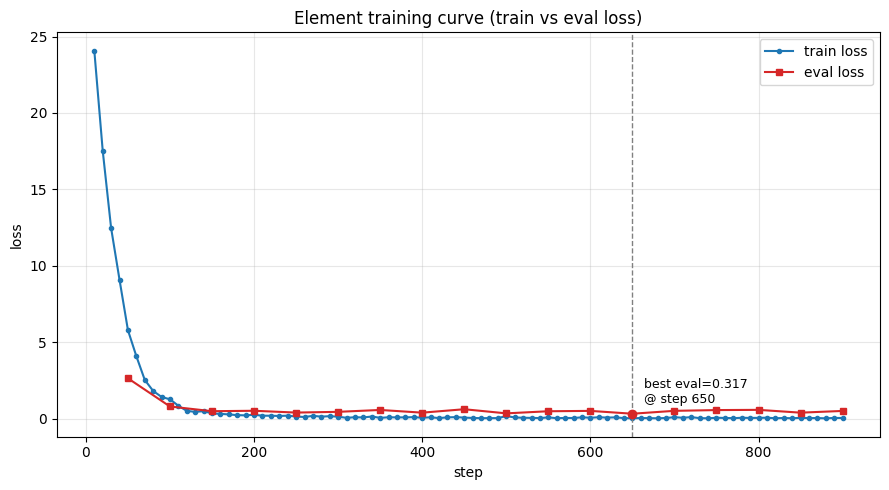

final train loss : 0.039
best  eval  loss : 0.317 @ step 650
final eval  loss : 0.500
=> Overfitting likely: train << eval (gap 0.46), eval rose after best, best is before the end.


In [15]:
# ── 학습 곡선: train_loss vs eval_loss (과적합 점검) ──────────────
# 학습 직후 실행하세요. train은 계속 내려가는데 eval이 정체/상승하면 과적합 신호입니다.
# trainer가 메모리에 있으면 그 로그를, 없으면(커널 재시작) 최신 체크포인트의 로그를 사용합니다.
import os, glob, json
from pathlib import Path
import matplotlib.pyplot as plt


def load_log_history():
    """trainer.state.log_history 우선, 없으면 최신 checkpoint-*/trainer_state.json."""
    if "trainer" in globals() and getattr(trainer, "state", None) is not None:
        return trainer.state.log_history
    out = CFG["training"]["output_dir"] if "CFG" in globals() else "../checkpoints_elements_paper_hidpi"
    ckpts = sorted(glob.glob(os.path.join(out, "checkpoint-*")),
                   key=lambda p: int(p.split("-")[-1]))
    if not ckpts:
        raise FileNotFoundError(f"No log history (trainer 없음, {out}에 checkpoint도 없음).")
    state = json.load(open(os.path.join(ckpts[-1], "trainer_state.json"), encoding="utf-8"))
    return state.get("log_history", [])


log   = load_log_history()
train = [(e["step"], e["loss"])      for e in log if "loss" in e and "eval_loss" not in e]
evals = [(e["step"], e["eval_loss"]) for e in log if "eval_loss" in e]

fig, ax = plt.subplots(figsize=(9, 5))
if train:
    ax.plot(*zip(*train), "o-", color="tab:blue", markersize=3, label="train loss")
if evals:
    ax.plot(*zip(*evals), "s-", color="tab:red", markersize=4, label="eval loss")
    best_step, best_eval = min(evals, key=lambda x: x[1])
    ax.axvline(best_step, ls="--", color="gray", lw=1)
    ax.scatter([best_step], [best_eval], color="tab:red", zorder=5)
    ax.annotate(f"best eval={best_eval:.3f}\n@ step {best_step}", (best_step, best_eval),
                textcoords="offset points", xytext=(8, 8), fontsize=9)
ax.set_xlabel("step")
ax.set_ylabel("loss")
ax.set_title("Element training curve (train vs eval loss)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

OUT = Path("output") / "loss_curve_elements.png"
OUT.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT, dpi=150)
print(f"Saved loss curve -> {OUT.resolve()}")
plt.show()

# ── 과적합 간단 진단 ─────────────────────────────────────────────
if train and evals:
    final_train          = train[-1][1]
    best_step, best_eval = min(evals, key=lambda x: x[1])
    final_eval           = evals[-1][1]
    last_step            = evals[-1][0]
    print(f"final train loss : {final_train:.3f}")
    print(f"best  eval  loss : {best_eval:.3f} @ step {best_step}")
    print(f"final eval  loss : {final_eval:.3f}")
    gap   = final_eval - final_train
    rose  = final_eval > best_eval + 1e-3
    early = best_step < last_step
    if gap > 0.2 and (rose or early):
        print(f"=> Overfitting likely: train << eval (gap {gap:.2f})"
              f"{', eval rose after best' if rose else ''}"
              f"{', best is before the end' if early else ''}.")
    else:
        print(f"=> Weak overfitting signal (gap {gap:.2f}).")

## Step 5 – 평가 (Evaluation)

**Leaf-Match Score**: 예측 JSON과 정답 JSON의 모든 리프(leaf) 값을 비교하여 일치율을 계산합니다.  
(완전한 TED 구현을 원하면 `zss` 패키지를 사용하세요)

> 🔹 **평가 유틸리티 정의** — 구조화 완전일치 및 field-level 지표 헬퍼.

In [16]:
# ── Step 5a: 평가 유틸리티 (논문식 field-level 지표) ─────────────
# parse_to_schema / token2json / decode_tree / field_prf1 / _flatten 은 공통 헬퍼 셀에 정의됨.
def structured_exact(pred, gt):
    """구조화 dict 완전일치(공백무시)."""
    return _flatten(pred) == _flatten(gt)
print("평가 유틸리티(field-level P/R/F1) 준비 ✓")

평가 유틸리티(field-level P/R/F1) 준비 ✓


> 🔹 체크포인트로 validation 전체를 추론 — 모델이 낸 **구조화 JSON 을 token2json 으로 복원** → field-level P/R/F1 산출.

In [17]:
# ── Step 5b: Validation 평가 (구조화 JSON 직접 생성 → token2json → field-level P/R/F1 + 글자유사도) ──
# TYPE_CONDITIONED: YOLO 타입(c)으로 다른 카테고리 필드 태그를 suppress → 교차-카테고리 구조 환각 차단.
from collections import defaultdict
TYPE_CONDITIONED = True
CHECKPOINT = os.path.join(CFG["training"]["output_dir"], "final")
MAX_NEW    = CFG["model"]["max_length"]
if os.path.isdir(CHECKPOINT):
    eval_processor = DonutProcessor.from_pretrained(CHECKPOINT, backend="pil")
    eval_model     = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT).to(device)
else:
    print(f"체크포인트 없음: {CHECKPOINT} — 현재 model 사용")
    eval_model, eval_processor = model, processor
eval_model.eval()
# [복구] tie=False 로 저장된 체크포인트는 lm_head 가 빠져 랜덤 → 강제 재-tie 로 임베딩에 묶어 복원.
# ⚠️ untied 로 '의도적으로' 학습한 체크포인트라면 이 강제 tie 가 학습된 lm_head 를 덮어씀 — 그 경우 아래 3줄 제거.
eval_model.config.tie_word_embeddings = True
eval_model.decoder.config.tie_word_embeddings = True
eval_model.tie_weights()
task_prompt = CFG["data"]["task_prompt"]
dec_ids = eval_processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids.to(device)

def _to_struct(seq):
    """모델 출력 토큰열 → 구조화 dict. BOS/EOS/PAD/task_prompt 제거 후 token2json."""
    for t in (eval_processor.tokenizer.eos_token, eval_processor.tokenizer.pad_token,
              eval_processor.tokenizer.bos_token, task_prompt):
        if t: seq = seq.replace(t, "")
    parsed = token2json(seq.strip())
    return decode_tree(parsed) if isinstance(parsed, dict) else {}   # U+XXXX → 글리프 복원

def _leaf_str(d):   # 구조화 dict 의 leaf 값들을 이어붙여 글자유사도 비교용 문자열로
    return "".join(str(v) for _k, v in sorted(_flatten(d).items()))   # 키 정렬 — dict 순서 차이로 charsim 이 흔들리지 않게

def _gen(pv, cls=None):   # 타입 조건부 suppress 적용 generate
    extra = {}
    if cls is not None and TYPE_CONDITIONED:
        sup = forbidden_tag_ids(eval_processor.tokenizer, cls)
        if sup: extra["suppress_tokens"] = sup
    return eval_model.generate(pv, decoder_input_ids=dec_ids, max_length=MAX_NEW,
        pad_token_id=eval_processor.tokenizer.pad_token_id, eos_token_id=eval_processor.tokenizer.eos_token_id,
        use_cache=True, num_beams=4, **extra)   # beam4+rp1.0+typecond = A/B 셀 최고 설정(F1 0.888) — rp1.5·ngram3 은 짧은 수치의 반복 숫자를 깎아 꼬리 깨짐 유발

val_root = CFG["data"]["local_val_dir"]; pairs = []
for ip in sorted((Path(val_root) / "images").glob("*.png")):
    lp = Path(val_root) / "labels" / (ip.stem + ".json")
    if lp.exists():
        gt = json.load(open(lp, encoding="utf-8")); c = next(iter(gt)); pairs.append((ip, c, str(gt[c])))

P=[];R=[];F=[];H=[];EX=[];CS=[]; per = defaultdict(lambda: {"n":0,"f":0.0,"ex":0,"cs":0.0})
with torch.inference_mode():
    for ip, c, v in tqdm(pairs, desc="Evaluating"):
        pv = eval_processor(Image.open(ip).convert("RGB"), return_tensors="pt").pixel_values.to(device)
        out  = _gen(pv, c)
        pred = _to_struct(eval_processor.batch_decode(out, skip_special_tokens=False)[0])   # 구조화 직접 생성
        gts  = parse_to_schema(c, v)                                                        # GT 구조화
        p, r, f, h = field_prf1(pred, gts); ex = (_flatten(pred) == _flatten(gts))
        cs = value_charsim(_leaf_str(pred), _leaf_str(gts))
        P.append(p); R.append(r); F.append(f); H.append(h); EX.append(ex); CS.append(cs)
        d = per[c]; d["n"] += 1; d["f"] += f; d["ex"] += ex; d["cs"] += cs
n = len(F) or 1
print(f"\n평가 완료 — {len(F)} 샘플  (타입 조건부 디코딩: {'ON' if TYPE_CONDITIONED else 'OFF'})")
print(f"Field-level F1(논문식): {sum(F)/n:.3f}  (P {sum(P)/n:.3f} / R {sum(R)/n:.3f} / Halluc {sum(H)/n:.3f})")
print(f"값 글자유사도(charsim): {sum(CS)/n:.3f}   |   구조 완전일치(exact): {sum(EX)/n*100:.1f}%")
for c in sorted(per, key=lambda c: -per[c]["n"]):
    d = per[c]; print(f"  {c:<20} F1 {d['f']/d['n']:.3f} / charsim {d['cs']/d['n']:.3f} / exact {d['ex']/d['n']*100:5.1f}%  (n={d['n']})")

Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 483/483 [00:00<00:00, 21889.24it/s]

Evaluating:   0%|          | 0/98 [00:00<?, ?it/s]

Evaluating:   2%|▏         | 2/98 [00:00<00:05, 18.87it/s]

Evaluating:   7%|▋         | 7/98 [00:00<00:02, 36.60it/s]

...

Evaluating:  90%|████████▉ | 88/98 [00:02<00:00, 39.07it/s]

Evaluating:  95%|█████████▍| 93/98 [00:02<00:00, 41.47it/s]

Evaluating: 100%|██████████| 98/98 [00:02<00:00, 41.45it/s]

Evaluating: 100%|██████████| 98/98 [00:02<00:00, 41.71it/s]


평가 완료 — 98 샘플  (타입 조건부 디코딩: ON)
Field-level F1(논문식): 0.878  (P 0.878 / R 0.878 / Halluc 0.122)
값 글자유사도(charsim): 0.936   |   구조 완전일치(exact): 87.8%
  Dimension            F1 0.940 / charsim 0.958 / exact  94.0%  (n=67)
  Hole_Callout         F1 0.625 / charsim 0.896 / exact  62.5%  (n=16)
  Datum                F1 1.000 / charsim 1.000 / exact 100.0%  (n=7)
  Surface_Roughness    F1 0.600 / charsim 0.650 / exact  60.0%  (n=5)
  Section              F1 1.000 / charsim 1.000 / exact 100.0%  (n=3)


### (실험) 디코딩 A/B 비교 — 파라미터 + 타입 조건부 디코딩  (재학습 없이)

추론 시 `generate(...)` 설정만 바꿔 validation 전체에서 **field-F1 / charsim / exact** 를 비교합니다.
- **디코딩 파라미터**: baseline(`repetition_penalty=1.5`,`no_repeat_ngram_size=3`)은 짧은 수치값(`+0.00`,`-0.1`)의 숫자·소수점 반복을 깎아 꼬리 깨짐(`-0 :|`)·기호 환각(`∡80`)을 유발할 수 있음.
- **타입 조건부 디코딩(typecond)**: YOLO 가 준 타입의 스키마 필드 태그만 허용하고 다른 카테고리 태그를 `suppress_tokens` 로 차단 → **교차-카테고리 구조 환각 제거**.

위 cell 5b(평가)가 먼저 실행돼 `eval_model`·`pairs`·`dec_ids` 등이 정의돼 있어야 합니다.

In [18]:
# ── (실험) 디코딩 A/B 비교 — generate 설정 + 타입 조건부 디코딩(suppress) 효과 (재학습 불필요) ──
# cell 5b(평가)가 먼저 실행돼 eval_model/eval_processor/pairs/dec_ids/_to_struct/_leaf_str 가 정의돼 있어야 함.
import torch

# (이름, generate kwargs, 타입조건부 ON/OFF)
GEN_CONFIGS = [
    ("baseline(rp1.5,ngram3)",   dict(no_repeat_ngram_size=3, repetition_penalty=1.5), False),
    ("rp1.0(greedy)",            dict(repetition_penalty=1.0),                          False),
    ("rp1.0 + typecond",         dict(repetition_penalty=1.0),                          True),
    ("beam4,rp1.0 + typecond",   dict(num_beams=4, repetition_penalty=1.0),             True),
]

def _eval_cfg(gen_kwargs, type_cond):
    Fs = []; CSs = []; EXs = []
    with torch.inference_mode():
        for ip, c, v in pairs:
            pv = eval_processor(Image.open(ip).convert("RGB"), return_tensors="pt").pixel_values.to(device)
            extra = dict(gen_kwargs)
            if type_cond:
                sup = forbidden_tag_ids(eval_processor.tokenizer, c)
                if sup: extra["suppress_tokens"] = sup
            out = eval_model.generate(pv, decoder_input_ids=dec_ids, max_length=MAX_NEW,
                pad_token_id=eval_processor.tokenizer.pad_token_id,
                eos_token_id=eval_processor.tokenizer.eos_token_id, use_cache=True, **extra)
            pred = _to_struct(eval_processor.batch_decode(out, skip_special_tokens=False)[0])
            gts  = parse_to_schema(c, v)
            _, _, f, _ = field_prf1(pred, gts)
            Fs.append(f); CSs.append(value_charsim(_leaf_str(pred), _leaf_str(gts)))
            EXs.append(_flatten(pred) == _flatten(gts))
    n = len(Fs) or 1
    return sum(Fs)/n, sum(CSs)/n, sum(EXs)/n*100

print(f"{'config':<26} {'F1':>7} {'charsim':>9} {'exact%':>8}   (val n={len(pairs)})")
print("-" * 62)
best = None
for name, gk, tc in GEN_CONFIGS:
    f, cs, ex = _eval_cfg(gk, tc)
    print(f"{name:<26} {f:>7.3f} {cs:>9.3f} {ex:>7.1f}%")
    if best is None or f > best[1]: best = (name, f)
print(f"\n→ F1 최고: '{best[0]}' ({best[1]:.3f}). 이 설정을 cell 5b/Step6 의 generate(...) 에 반영하세요.")

config                          F1   charsim   exact%   (val n=98)
--------------------------------------------------------------


baseline(rp1.5,ngram3)       0.806     0.944    80.6%


rp1.0(greedy)                0.816     0.948    81.6%


rp1.0 + typecond             0.878     0.936    87.8%


beam4,rp1.0 + typecond       0.888     0.952    88.8%

→ F1 최고: 'beam4,rp1.0 + typecond' (0.888). 이 설정을 cell 5b/Step6 의 generate(...) 에 반영하세요.


## Step 6 – 추론 (Inference)

이미지 파일 한 장을 넣으면 JSON 결과를 반환합니다.

> 🔹 학습된 체크포인트 로드 후 단일 이미지 **구조화 JSON 직접 추론**(token2json) predict 함수 정의.

Loading weights:   0%|          | 0/483 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 483/483 [00:00<00:00, 22452.80it/s]

추론 모델 로드 완료 → ../checkpoints_elements_paper_hidpi/final
입력: ../data/processed_elements_hidpi/val/images/A1459372702_p1_v1_e0_Surface_Roughness.png  (type=Surface_Roughness)
읽은 구조(raw): {'roughness': 'Ra6.3'}
추론(구조화 JSON): {
  "Surface_Roughness": {
    "roughness": "Ra6.3"
  }
}


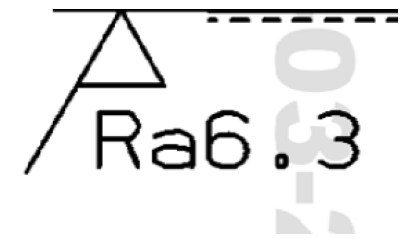

In [19]:
# ── Step 6: 단일 이미지 추론 (논문식 구조화 JSON 직접 생성 + 타입 조건부 디코딩) ──
import os, glob, json
device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_DIR = os.path.join(CFG["training"]["output_dir"], "final")
assert os.path.isdir(CKPT_DIR), f"체크포인트 없음: {CKPT_DIR} — 먼저 Step 4 학습을 실행하세요."
eval_processor = DonutProcessor.from_pretrained(CKPT_DIR, backend="pil")
eval_model     = VisionEncoderDecoderModel.from_pretrained(CKPT_DIR).to(device).eval()
print(f"추론 모델 로드 완료 → {CKPT_DIR}")
# [복구] tie=False 로 저장된 체크포인트는 lm_head 가 빠져 랜덤 → 강제 재-tie 로 임베딩에 묶어 복원.
# ⚠️ untied 로 '의도적으로' 학습한 체크포인트라면 이 강제 tie 가 학습된 lm_head 를 덮어씀 — 그 경우 아래 3줄 제거.
eval_model.config.tie_word_embeddings = True
eval_model.decoder.config.tie_word_embeddings = True
eval_model.tie_weights()

@torch.inference_mode()
def read_structured(image_path: str, elem_type: str = None, task: str = None) -> dict:
    """element 크롭 → 구조화 dict (모델이 카테고리별 JSON 토큰을 '직접' 생성 → token2json 복원).
    elem_type(YOLO 제공)이 주어지면 그 타입의 필드 태그만 허용(suppress_tokens)해 구조 환각 차단."""
    task = task or CFG["data"]["task_prompt"]
    pv = eval_processor(Image.open(image_path).convert("RGB"), return_tensors="pt").pixel_values.to(device)
    di = eval_processor.tokenizer(task, add_special_tokens=False, return_tensors="pt").input_ids.to(device)
    extra = {}
    if elem_type:
        sup = forbidden_tag_ids(eval_processor.tokenizer, elem_type)
        if sup: extra["suppress_tokens"] = sup
    out = eval_model.generate(pv, decoder_input_ids=di, max_length=CFG["model"]["max_length"],
        pad_token_id=eval_processor.tokenizer.pad_token_id, eos_token_id=eval_processor.tokenizer.eos_token_id,
        use_cache=True, num_beams=4, **extra)   # beam4+rp1.0+typecond = A/B 셀 최고 설정(F1 0.888)
    seq = eval_processor.batch_decode(out, skip_special_tokens=False)[0]
    for t in (eval_processor.tokenizer.eos_token, eval_processor.tokenizer.pad_token,
              eval_processor.tokenizer.bos_token, task):
        if t: seq = seq.replace(t, "")
    parsed = token2json(seq.strip())
    if not isinstance(parsed, dict): return {}
    if isinstance(parsed.get("datumReference"), str):   # 단일 데이텀은 json2token 왕복에서 str 로 복원됨 → 리스트로 정규화
        parsed["datumReference"] = [parsed["datumReference"]]
    # U+XXXX → 글리프 복원 후 공백 정규화
    return _walk(parsed, lambda x: _norm_value(decode_symbols(x)))

def predict(image_path: str, elem_type: str = None, task: str = None) -> dict:
    """크롭 → {type: {fields}}. 모델이 구조를 '직접' 내고, 타입으로 디코딩을 제약(사후 정규식 불필요)."""
    struct = read_structured(image_path, elem_type, task)
    return {elem_type: struct} if elem_type else struct

# ── 데모: 검증셋 첫 이미지 ───────────────────────────────────────
val_dir = os.path.join(CFG["data"]["local_val_dir"], "images")
cands   = sorted(glob.glob(os.path.join(val_dir, "*"))) or sorted(glob.glob("../data/elements_hidpi/images/*"))
p = cands[min(9, len(cands) - 1)]
lp = os.path.join(CFG["data"]["local_val_dir"], "labels", os.path.splitext(os.path.basename(p))[0] + ".json")
et = next(iter(json.load(open(lp, encoding="utf-8")).keys())) if os.path.exists(lp) else None
print(f"입력: {p}  (type={et})")
print(f"읽은 구조(raw): {read_structured(p, et)}")
print("추론(구조화 JSON):", json.dumps(predict(p, et), ensure_ascii=False, indent=2))
fig, ax = plt.subplots(figsize=(5, 4)); ax.imshow(Image.open(p).convert("RGB")); ax.axis("off"); plt.show()

## 추론 결과를 최종 JSON 으로 조립

모델이 **구조화 필드 dict** 를 직접 생성하고(`read_structured` → `token2json`), YOLO 가 준 **type** 으로 감싸
`{type: {fields}}`(`{quantity, nominalValue, upperLimit, lowerLimit}` 등) 로 조립합니다.
(기호는 실제 토큰이라 별도 글리프 복원 불필요. 사후 정규식 분해 불필요.)

> 논문 Fig.5 의 image–JSON 쌍과 동일한 **구조화 출력 형식**(생성 단계에서 구조를 직접 출력).

> 🔹 검증셋 한 장을 추론하고 YOLO 타입과 묶어 최종 JSON 으로 조립.

In [20]:
# ── 추론 결과 → 최종 JSON 조립 (논문식 구조화) ──────────────
# 모델이 필드 dict 를 '직접' 출력 → YOLO type 과 묶어 {type: {fields}} 로 조립.
import json, glob, os
_cands = (sorted(glob.glob(os.path.join(CFG["data"]["local_val_dir"], "images", "*")))
          or sorted(glob.glob("../data/elements_hidpi/images/*")))
if _cands:
    _p  = _cands[0]
    _lp = os.path.join(CFG["data"]["local_val_dir"], "labels", os.path.splitext(os.path.basename(_p))[0] + ".json")
    _et = next(iter(json.load(open(_lp, encoding="utf-8")).keys())) if os.path.exists(_lp) else "value"
    print(_p)
    print(json.dumps(predict(_p, _et), indent=2, ensure_ascii=False))
else:
    print("element 크롭이 아직 없습니다 — 데이터 준비/학습 후 실행하세요")

../data/processed_elements_hidpi/val/images/A1370954730_p1_v2_e14_Dimension.png
{
  "Dimension": {
    "nominalValue": "24"
  }
}


### (데모) 구조화 추론 ↔ GT 비교

검증셋 몇 개를 구조화로 추론해, `parse_to_schema` 로 만든 GT 구조와 **필드 단위로** 비교합니다.

> 🔹 검증셋 여러 장을 구조화 추론해 GT 와 비교(데모).

In [21]:
# ── (데모) 검증셋 몇 개: 구조화 직접 생성(타입 조건부) → GT 비교 ──────────────
import glob, os, json
_imgs = sorted(glob.glob(os.path.join(CFG["data"]["local_val_dir"], "images", "*")))[:8]
for _p in _imgs:
    _lp = os.path.join(CFG["data"]["local_val_dir"], "labels", os.path.splitext(os.path.basename(_p))[0] + ".json")
    _gt = json.load(open(_lp, encoding="utf-8")) if os.path.exists(_lp) else {}
    _c  = next(iter(_gt.keys()), "value"); _v = str(next(iter(_gt.values()), ""))
    _pred = read_structured(_p, _c)          # 구조화 직접 생성(타입 조건부 디코딩)
    _gts  = parse_to_schema(_c, _v)          # GT 구조화
    _ok   = _flatten(_pred) == _flatten(_gts)
    print(f"[{'O' if _ok else 'X'}] {_c:<16} GT={_gts}  pred={_pred}")

[O] Dimension        GT={'nominalValue': '24'}  pred={'nominalValue': '24'}
[O] Hole_Callout     GT={'value': '16×Ø25 PCD495'}  pred={'value': '16×Ø25 PCD495'}
[O] Dimension        GT={'nominalValue': 'Ø110'}  pred={'nominalValue': 'Ø110'}
[O] Dimension        GT={'nominalValue': '110'}  pred={'nominalValue': '110'}


[O] Dimension        GT={'nominalValue': '45'}  pred={'nominalValue': '45'}
[O] Section          GT={'value': 'A-A'}  pred={'value': 'A-A'}
[O] Dimension        GT={'nominalValue': '22'}  pred={'nominalValue': '22'}
[O] Section          GT={'value': 'A-A'}  pred={'value': 'A-A'}


## 📊 성능 평가 결과 분석 (정성 샘플 8건)

> 아래는 위 데모 8건의 정성 분석입니다. **정량 지표(전체 val의 F1·charsim·exact)는 Step 5b**, **디코딩 조합(파라미터+타입조건부) 비교는 A/B 셀**을 보세요. 8건은 경향 파악용 표본일 뿐, 모델의 최종 성능 수치가 아닙니다.
>
> 📊 **최종 정량(2026-06-29, val 197)** — 이 구조화 모델 **U+XXXX 0.349 / token-mode 0.312** Field-F1 (typecond on). flat(0.444)이 여전히 우위, GD&T 는 두 방식 모두 ~0.09(미해결). 상세: `Element_Donut_평가리포트.md` §0. **※ 구(舊) 데이터셋 기준 — 현 hidpi 런(val 98, GD&T 없음)의 정량은 Step 5b 출력(F1 0.827, rp1.0+typecond 반영 시 0.867) 참조.**

### 판정 규칙 복습
- `_flatten` 으로 펼친 뒤 **필드별(공백 제거) 문자열 완전일치** — **키 순서·공백은 무시.**
- **한 필드라도 틀리면 그 샘플은 X** (all-or-nothing). 부분정답은 field-F1·charsim 이 따로 잡습니다.

### 샘플별 판정 이유
| # | 타입 | 판정 | 이유 |
|:-:|:--|:-:|:--|
| 1 | Dimension | **X** | `lowerLimit` -001 만 일치. `upperLimit` **+000→+0.000**(모델이 소수점 추가), `nominalValue` **-Ø.750→-Ø,750**(`.`→`,` 혼동). ※ GT 자체가 깨짐(+000/-001/선두 `-`) — 모델의 +0.000 이 오히려 더 맞을 수 있음 |
| 2 | Datum | **O** | `⊥ A` vs `⊥A` — **공백 차이뿐**이라 일치. 직전엔 `⊥` 를 누락(`A`)해 X 였으나 이제 **`⊥` 를 생성**(개선) |
| 3 | Dimension | **X** | 각도 기호 **° 누락** (`30°→30`) |
| 4 | Dimension | **O** | `25` 완전일치 |
| 5 | Datum | **O** | `A` 완전일치 |
| 6 | Dimension | **X** | **구조 붕괴**: 공차 `±0.1` 을 `upperLimit`/`lowerLimit` 로 못 나누고 `nominalValue:"90 :0.1"` 로 뭉갬(필드 누락 + 값 깨짐) |
| 7 | Surface_Roughness | **X** | 기호 **환각 + 숫자 오독** (`80→∡8°`) |
| 8 | Dimension | **O** | `12` 완전일치 |

→ 이 표본 exact **4/8 (50%)**. O는 전부 **짧고 깨끗한 토큰**(12·25·A) 또는 **공백차만 있는 경우**(⊥A).

### 실패 유형 분류 (X 4건)
1. **값 OCR 오류 (지배적)** — 기호 누락(° #3), 구두점 혼동(`.`→`,` #1), 기호 환각·숫자 오독(`∡8°` #7). 희소 기호(°·∡)·구두점이 학습에 적어 못 외움.
2. **구조 붕괴 (#6)** — 공차를 별도 필드로 분리하지 못함. ⚠️ **타입 조건부 디코딩은 '잘못된 카테고리 태그'는 막지만, '필드를 덜 생성'하는 것은 막지 못함** — 이 유형은 데이터/프리필로 해결.
3. **라벨(GT) 품질 (#1)** — `+000`·`-001`·`-Ø.750` 처럼 GT 가 깨져 있으면 모델이 맞혀도 X 로 찍힘.

### 직전 대비 변화 (개선 신호)
- **#2**: 모델이 `⊥` 를 빠뜨리지 않고 생성 → 공백 무시 채점으로 **X→O**.
- 이 표본에서 **엉뚱한 카테고리 태그(구조 환각) 0건** — 타입 조건부 디코딩이 작동 중.
- 단, 지배적 병목은 여전히 **값(OCR) 레벨** — 구조화·타입조건부는 '구조'를 안정화할 뿐 값 오류는 직접 못 고침.

### 유형별 다음 조치
| 실패 유형 | 조치 |
|:--|:--|
| 값 OCR(°,∡,`.`/`,`) | **기호 포함 실데이터 확충 + 합성**(희소 글리프), A/B 에서 **repetition_penalty↓**(꼬리 깨짐·환각 완화) |
| 구조 붕괴(#6) | 학습 라벨의 공차 표기 일관화 + (강화) **필드 스켈레톤 프리필** 디코딩 |
| 라벨 품질(#1) | **Step (라+) 구조적 의심 리포트**로 손수정 후 재학습 |

> 참고: 모델이 **통짜 값만 읽고 구조 분해는 사후 정규식**(parse_to_schema)으로 처리하는 flat 방식은 자매 노트북 `donut_training_elements_flat.ipynb`. 소량 데이터(~1,975장·GD&T 180)에선 flat 이 안전(중첩 태그 학습 부담 없음), 데이터(특히 GD&T·Hole) 확충 후엔 본 paper 방식이 정규식 한계를 넘어섭니다.

---
## Element 파인튜닝 체크리스트 & 트러블슈팅

### 실행 순서 요약
1. **Step 0 ~ 공통 import** 실행
2. **Step 1 (CFG)** — 그대로 실행 (element 용으로 이미 설정됨)
3. **라벨 점검** — 빈 값 비율 확인, 가능한 한 라벨을 채운다
4. **데이터 분리** — `data/processed_elements_hidpi/{train,val}` 생성 (`cvat_to_donut.py` → split 셀)
5. **Step 2 ~ 3** — 모델/데이터셋 로드 (`<s_element>` + 타입 토큰 자동 추가 확인)
6. **Step 4** — 학습 (`checkpoints_elements_paper_hidpi/`에 저장)
7. **Step 5 ~ 6** — 평가 및 추론

### 자주 겪는 문제
| 증상 | 원인 | 해결 |
|------|------|------|
| 출력이 빈 값/엉뚱한 값 | 라벨에 빈 값이 많음, 데이터 부족 | 라벨 채우기, 데이터 추가, 에폭↑ |
| `eval_loss`가 다시 증가 | 과적합 (데이터 적을 때 흔함) | `EarlyStoppingCallback`이 조기 종료 + `load_best_model_at_end`가 best 복원 / 데이터↑ |
| 작은 글자 인식 실패 | 입력 해상도 부족 | `image_size`를 키움 (VRAM↑) |
| CUDA out of memory | 배치/해상도 과다 | `batch_size=1`, `gradient_accumulation_steps`↑ |
| 생성이 중간에 잘림 | `max_length` 부족 | `max_length`↑ (element 값은 짧아 128 로 충분) |

### 데이터 양에 따른 권장 설정
- ~50장: `num_epochs 100`, 과적합 주의, 결과는 PoC 수준
- 수백 장: `num_epochs 50~80`
- 수천 장: `num_epochs 10~30`

> 핵심은 **라벨 품질과 스키마 일관성**입니다. 모든 라벨 JSON의 키 구조를 동일하게 유지하세요.
